## 0. Load packages and dataset

In [86]:
import numpy as np
import pooch
import scanpy as sc
import pandas as pd
import os
import polars as pl
from plotnine import * 
import matplotlib.pyplot as plt


In [87]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # display all outputs

In [88]:
graphs_dir = "../outputs/figures/00_initial_exploration/"

In [89]:
file_path = pooch.retrieve(
    url="https://datasets.cellxgene.cziscience.com/f34d2b82-9265-4a73-bda4-852933bf2a8d.h5ad",
    known_hash=None,  # Pooch will print the hash for you after the first download
    fname="cellxgene_intestine.h5ad",
    path="../data",
    progressbar=True
)

In [90]:
# read data
adata = sc.read_h5ad("../data/cellxgene_intestine.h5ad")

In [ ]:
# first inspection of adata structure
print(adata)
print(adata.layers.keys())
print(adata.X[:100, :100].toarray()) # X slot contains normalised data, but there are no layers with raw?

AnnData object with n_obs × n_vars = 428469 × 32383
    obs: 'donor_id', 'Diagnosis', 'Fraction', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'author_cell_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'suspension_type', 'hca_data_portal_donor_uuid', 'hca_data_portal_cellsuspension_uuid', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'feature_types', 'feature_is_filtered', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'category_color

## 1. Inspection of features and annotations (.var)

In [ ]:
print(adata.var.shape) #32383 genes described by 13 columns
print(adata.var.columns)
print(adata.var_names[:10]) # check index (row label) -> in ENSEMBL IDs
print(adata.raw.X) #raw data location found with schema in cellxgene website

(32383, 13)
Index(['n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts',
       'total_counts', 'n_cells', 'feature_types', 'feature_is_filtered',
       'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype',
       'feature_length', 'feature_type'],
      dtype='str')
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000239945', 'ENSG00000239906', 'ENSG00000241599',
       'ENSG00000236601', 'ENSG00000284733', 'ENSG00000235146',
       'ENSG00000284662'],
      dtype='str')
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 758992343 stored elements and shape (428469, 32383)>
  Coords	Values
  (0, 14)	1.0
  (0, 50)	1.0
  (0, 99)	1.0
  (0, 150)	4.0
  (0, 212)	1.0
  (0, 219)	1.0
  (0, 238)	1.0
  (0, 261)	1.0
  (0, 263)	1.0
  (0, 317)	1.0
  (0, 334)	1.0
  (0, 369)	1.0
  (0, 451)	1.0
  (0, 476)	1.0
  (0, 478)	4.0
  (0, 542)	1.0
  (0, 544)	3.0
  (0, 550)	2.0
  (0, 569)	2.0
  (0, 593)	2.0
  (0, 601)	1.0
  (0, 626)	2.0
  (0, 633)

### 1.1. Identification & Mapping:

- gene_symbols: HGNC gene names, easy to read, only genes and null values

- feature_name: Contains HGNC gene names + ENSEMBL and other naming where they are not available

- feature_reference: Species identifier for human (same value)


In [93]:
print(adata.var['gene_symbols'].head()) # Contains standardized, HGNC-approved names, contains null values for features without an assigned symbol
print(adata.var['feature_name'].head()) # prioritizes standardized symbols where available but falls back to Ensembl IDs or temporary identifiers
adata.var['feature_name'].duplicated().any() # feature_names contains duplicates, compared to pure ENSEMBL
print(adata.var['feature_reference'].value_counts()) # Human species reference identifier

ENSG00000243485           NaN
ENSG00000237613       FAM138A
ENSG00000186092           NaN
ENSG00000239945           NaN
ENSG00000239906    AL627309.2
Name: gene_symbols, dtype: category
Categories (2833, str): ['AADACL3', 'AC000099.1', 'AC000372.1', 'AC002056.2', ..., 'ZNF705B', 'ZNF735', 'ZP4', 'hsa-mir-1253']
ENSG00000243485        MIR1302-2HG
ENSG00000237613            FAM138A
ENSG00000186092              OR4F5
ENSG00000239945    ENSG00000239945
ENSG00000239906    ENSG00000239906
Name: feature_name, dtype: category
Categories (32367, str): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZYX', 'ZZEF1', 'ZZZ3', 'hsa-mir-1253']


np.True_

feature_reference
NCBITaxon:9606    32383
Name: count, dtype: int64


### 1.2. Biological Classification:

- feature_biotype: The functional category of the gene (e.g., protein_coding, lncRNA, pseudogene).

- feature_length: The length of the genomic feature in base pairs.


In [94]:
print(adata.var['feature_biotype'].value_counts()) # only gene
print(adata.var['feature_type'].value_counts()) # kind of gene
print(adata.var['feature_length'].astype(float).min()) # min gene length
print(adata.var['feature_length'].astype(float).max()) # max gene length


feature_biotype
gene    32383
Name: count, dtype: int64
feature_type
protein_coding                        19690
lncRNA                                11952
IG_V_pseudogene                         187
IG_V_gene                               146
TR_V_gene                               106
TR_J_gene                                79
transcribed_unprocessed_pseudogene       47
IG_D_gene                                37
TR_V_pseudogene                          33
transcribed_unitary_pseudogene           20
IG_J_gene                                18
artifact                                 17
IG_C_gene                                14
IG_C_pseudogene                           9
transcribed_processed_pseudogene          8
TR_C_gene                                 6
TR_D_gene                                 4
TR_J_pseudogene                           4
IG_J_pseudogene                           3
unprocessed_pseudogene                    2
processed_pseudogene                      1
Name: c

### 1.3. Experimental Modality

- feature_type: Specifies the measurement technology used for that row (Gene Expression for RNA-seq).



In [95]:
print(adata.var['feature_types'].value_counts()) # only Gene Expression, so where are TCRs?

feature_types
Gene Expression    32383
Name: count, dtype: int64


### 1.4. Technical Quality Control (QC)

- n_cells:

- n_cells_by_counts: Total number of cells in which a specific feature was detected.

- total_counts: The cumulative sum of all UMIs/counts assigned to this feature across the entire dataset.

- mean_counts: The average expression intensity of the feature.

- pct_dropout_by_counts: The percentage of cells where the feature was not detected

- feature_is_filtered: A boolean flag indicating if the gene was excluded from downstream analysis during the initial preprocessing steps.


In [96]:
print(adata.var['n_cells'].head()) # number of cells that have at least one transcript (count > 0) for the gene
print(adata.var['n_cells_by_counts'].head()) # output of sc.pp.calculate_qc_metrics, but what is the difference

ENSG00000243485    64.0
ENSG00000237613     NaN
ENSG00000186092     3.0
ENSG00000239945    43.0
ENSG00000239906     NaN
Name: n_cells, dtype: float64
ENSG00000243485    75.0
ENSG00000237613     NaN
ENSG00000186092     5.0
ENSG00000239945    58.0
ENSG00000239906     NaN
Name: n_cells_by_counts, dtype: float64


In [ ]:
print(adata.var['total_counts'].head()) # total counts on normalized data?
print(adata.var['mean_counts'].head()) 

ENSG00000243485    74.79665
ENSG00000237613         NaN
ENSG00000186092     5.00000
ENSG00000239945    57.96968
ENSG00000239906         NaN
Name: total_counts, dtype: float64
ENSG00000243485    0.000078
ENSG00000237613         NaN
ENSG00000186092    0.000005
ENSG00000239945    0.000060
ENSG00000239906         NaN
Name: mean_counts, dtype: float64


In [98]:
print(adata.var['pct_dropout_by_counts'].head()) # percentage of cells in your dataset where a specific gene was not detected

ENSG00000243485    99.992201
ENSG00000237613          NaN
ENSG00000186092    99.999480
ENSG00000239945    99.993969
ENSG00000239906          NaN
Name: pct_dropout_by_counts, dtype: float64


In [99]:

print(adata.var['feature_is_filtered'].value_counts()) # genes that were flagged for removal
print(adata.var['feature_is_filtered'].value_counts(normalize=True)) # genes that were flagged for removal

feature_is_filtered
False    29550
True      2833
Name: count, dtype: int64
feature_is_filtered
False    0.912516
True     0.087484
Name: proportion, dtype: float64


## 2. Inspection of cell metadata and sample annotations (.obs)

To better understand our dataset, we first have a look at all metadata available to us in adata.obs.

In [100]:

summary = []
for col in adata.obs.columns:
    n_unique = adata.obs[col].nunique()
    
    if n_unique < 10:
        # Join with <br> for HTML rendering or \n for the 'pre-wrap' style
        vals = sorted([str(v) for v in adata.obs[col].unique()])
        values_str = "\n".join(vals)
    else:
        values_str = "..."

    summary.append({
        "Column": col,
        "Unique": n_unique,
        "Dtype": str(adata.obs[col].dtype),
        "Values": values_str
    })

df_summary = pd.DataFrame(summary)

# This tells VS Code's table viewer to respect the \n line breaks
df_summary.style.set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'})

,Column,Unique,Dtype,Values
0,donor_id,38,category,...
1,Diagnosis,4,category,Healthy adult Pediatric Crohn Disease Pediatric healthy fetal
2,Fraction,5,category,SC SC-45N SC-45P SC-EPCAMN SC-EPCAMP
3,batch,159,category,...
4,n_genes,6984,int64,...
5,n_genes_by_counts,6984,int64,...
6,total_counts,426068,float64,...
7,total_counts_mt,420958,float64,...
8,pct_counts_mt,420240,float64,...
9,doublet_scores,4486,float64,...


### 2.1. Patient information

A closer look at the metadata reveals the following information (ontology ID is always an extra column):

- donor_id: 38 individuals

- Diagnosis: contains fetal, healthy adult, pediatric healthy and pediatric Chron's disease

- disease (ontology_term_id): Chrons disease and healthy

- Age_group: Adult/pediatric, Mesenteric Lymph Nodes (MLE) yes/no, fist/second trimester, pediatric IBD

- sex (ontology_term_id): Sex (M/F)

- self_reported_ethnicity (ontology_term_id): British (only 2 healthy adults) or unknown

In [101]:
# Check distribution of sex across diagnoses

d = (pl.from_pandas(adata.obs)
.select(["donor_id","Diagnosis","sex","Age_group", "self_reported_ethnicity"])
.unique()
.sort(pl.col("Diagnosis").cast(pl.String).str.to_lowercase()) #change fetal to Fetal in final metadata reformatting
)

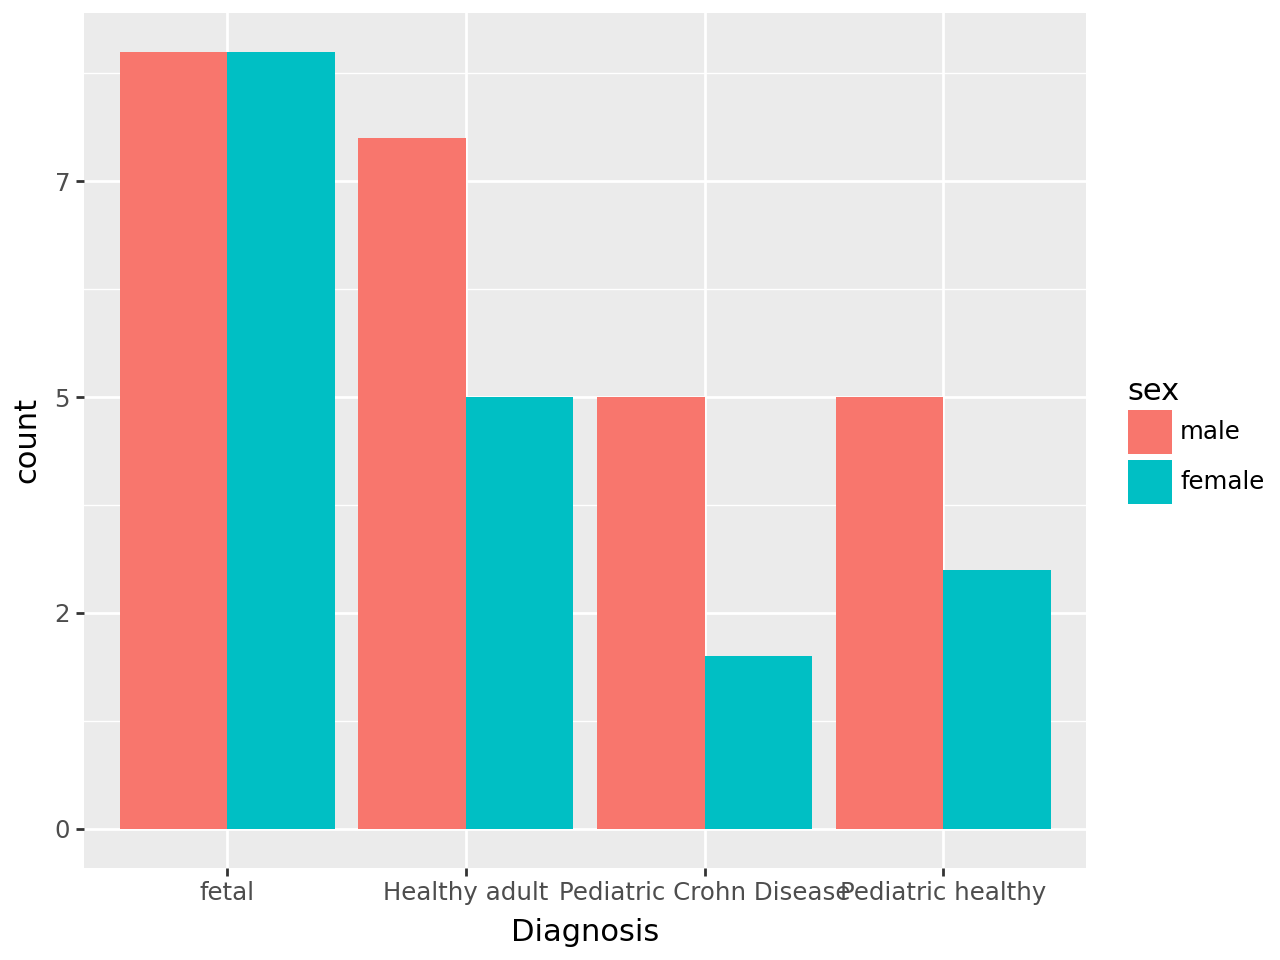

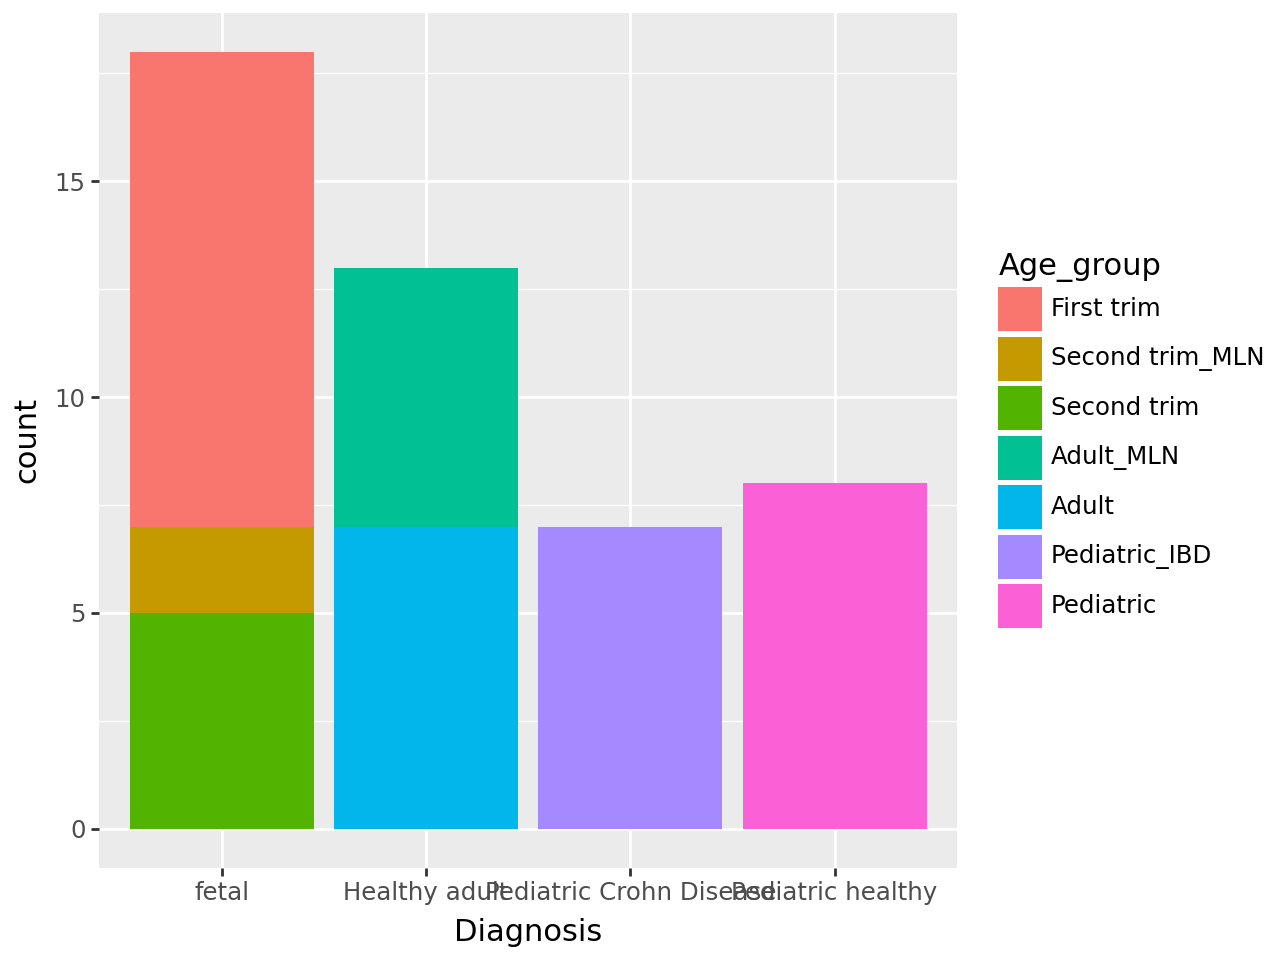

In [102]:
p1 = (ggplot(d, aes(x="Diagnosis", fill="sex")) 
       + geom_bar(position="dodge")
       + scale_y_continuous(labels=lambda x: [f"{int(val)}" for val in x]))

p2 = (ggplot(d, aes(x="Diagnosis", fill="Age_group"))
       + geom_bar())

p1
p2

In [103]:

save_as_pdf_pages([p1,p2], filename=f"{graphs_dir}01_patient_data_inspection.pdf")

/home/melrie/miniforge3/envs/hi/lib/python3.14/site-packages/plotnine/ggplot.py:797: PlotnineWarning: Filename: ../outputs/figures/00_initial_exploration/01_patient_data_inspection.pdf


In [104]:
# Check ethinicity information
(d.filter(pl.col("self_reported_ethnicity") == "British"))

donor_id,Diagnosis,sex,Age_group,self_reported_ethnicity
cat,cat,cat,cat,cat
"""A32 (411C)""","""Healthy adult""","""male""","""Adult_MLN""","""British"""
"""A32 (411C)""","""Healthy adult""","""male""","""Adult""","""British"""
"""A26 (386C)""","""Healthy adult""","""female""","""Adult""","""British"""
"""A26 (386C)""","""Healthy adult""","""female""","""Adult_MLN""","""British"""


### 2.2. Processing information (sorting, sequencing):

- Fraction: I assume from FACS sorting: single-cell, EPCAM positive (epithelial), EPCAM negative (not epithelial), CD45 positive (immune cell), CD45 negative (non-immune cell), they vary accross samples! (see plot)

- assay (ontology_term_id): Chemistry of sequencing, 10x Single Cell 3' v2 chemistry and 10x 5' v2, these being mixed in this dataset is important for integration, distribution is plotted below

- is_primary_data: TRUE/FALSE gives info if the dataset was produced for the publication or was included from another study

- unique_join_id: unique value given to cells for merging, subsetting etc

- batch: with 159 values that is still a bit of a mystery to me


In [105]:
d2 = (pl.from_pandas(adata.obs)
       .select(["donor_id","Diagnosis","Fraction","assay","is_primary_data"])
       .unique()
       .sort(pl.col("Diagnosis").cast(pl.String).str.to_lowercase())) #change fetal to Fetal in final metadata reformatting
d2

donor_id,Diagnosis,Fraction,assay,is_primary_data
cat,cat,cat,cat,bool
"""BRC2134""","""fetal""","""SC-EPCAMN""","""10x 3' v2""",false
"""BRC2121""","""fetal""","""SC-EPCAMP""","""10x 3' v2""",false
"""BRC2043""","""fetal""","""SC-EPCAMP""","""10x 3' v2""",false
"""F73""","""fetal""","""SC""","""10x 5' v2""",true
"""F72""","""fetal""","""SC""","""10x 5' v2""",true
…,…,…,…,…
"""T160""","""Pediatric healthy""","""SC-EPCAMP""","""10x 3' v2""",false
"""T024""","""Pediatric healthy""","""SC-EPCAMP""","""10x 3' v2""",false
"""T182""","""Pediatric healthy""","""SC-EPCAMP""","""10x 3' v2""",false


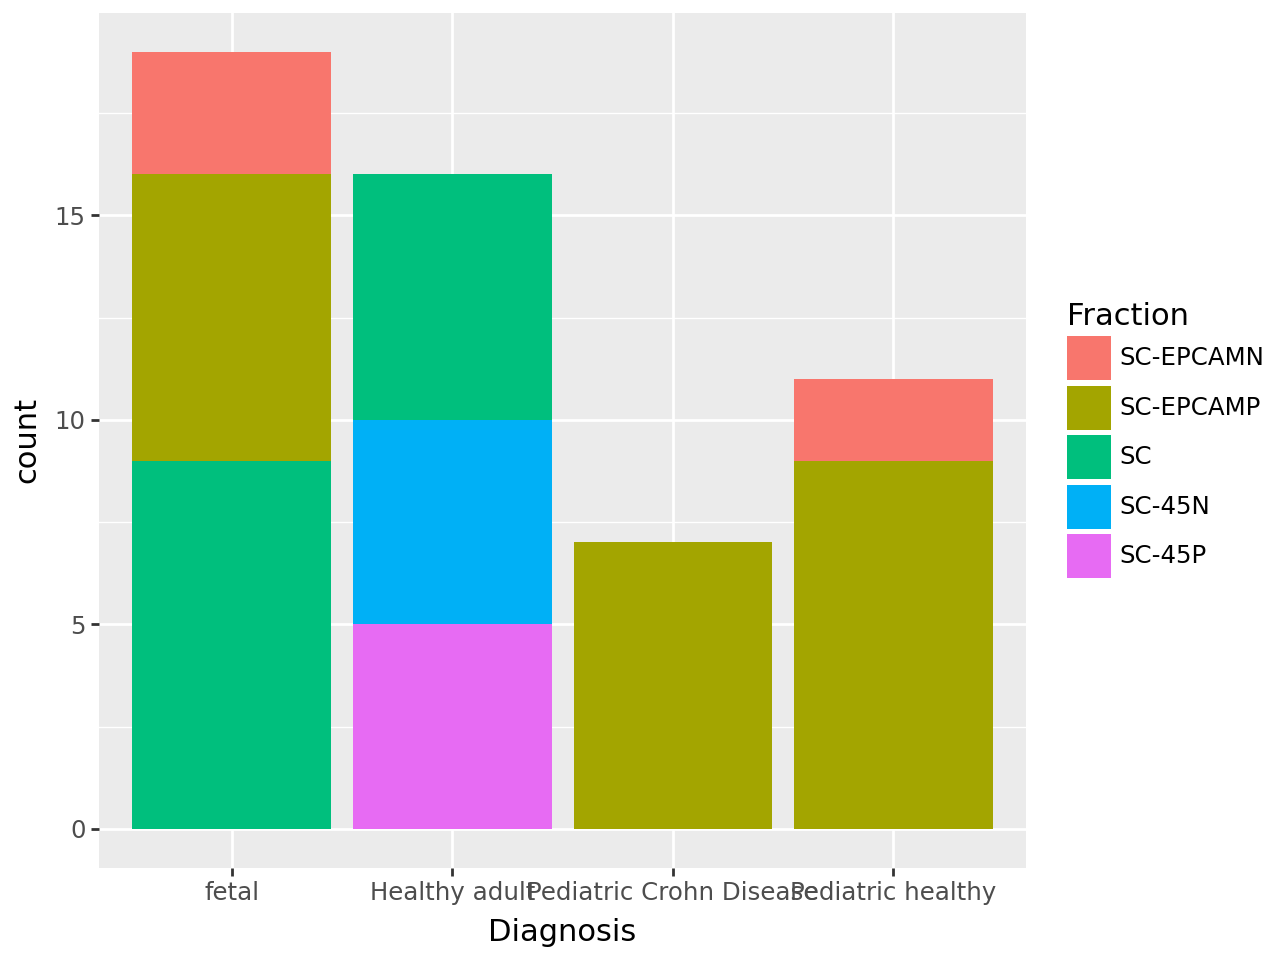

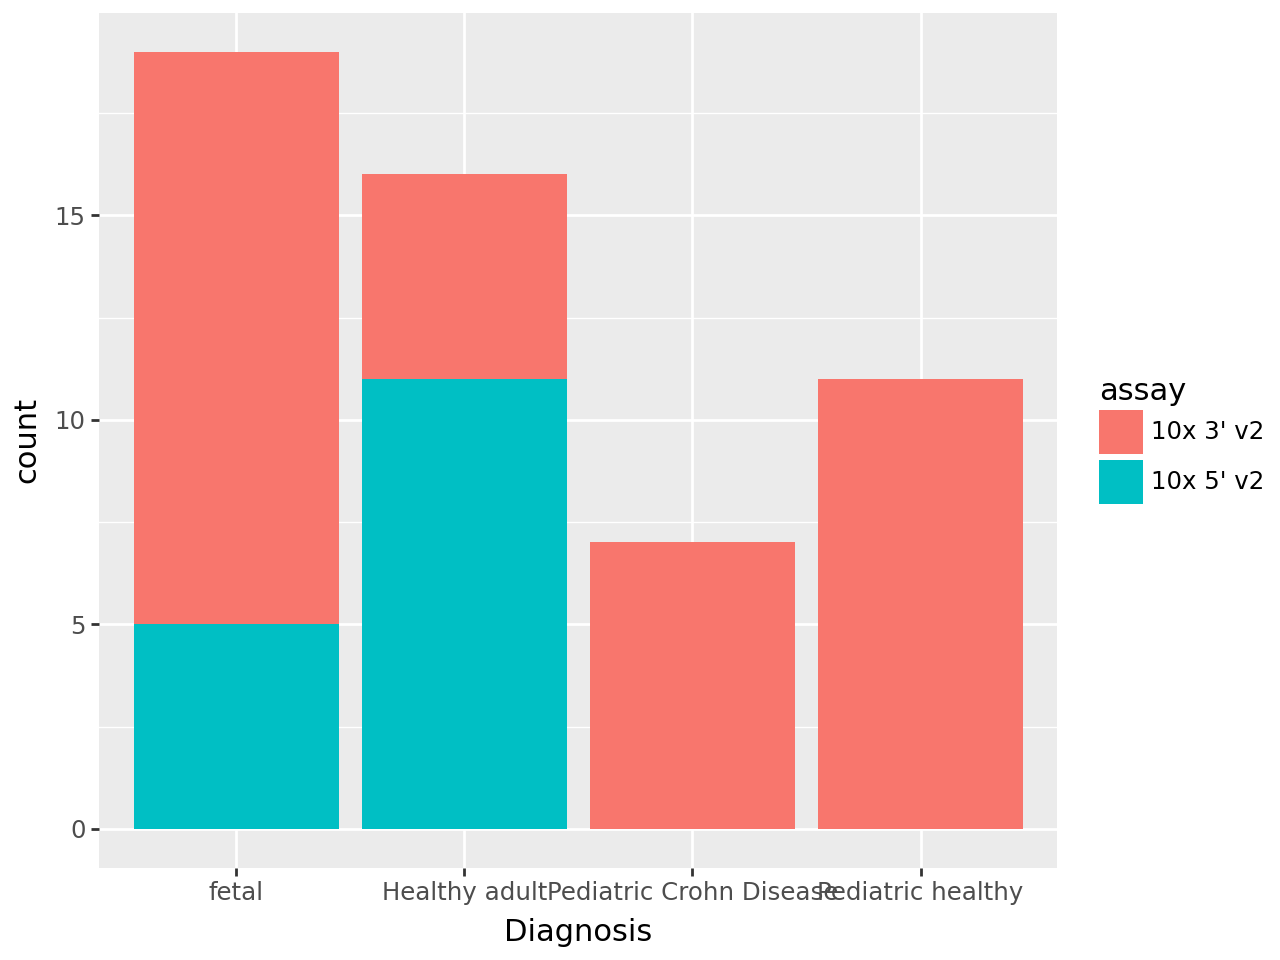

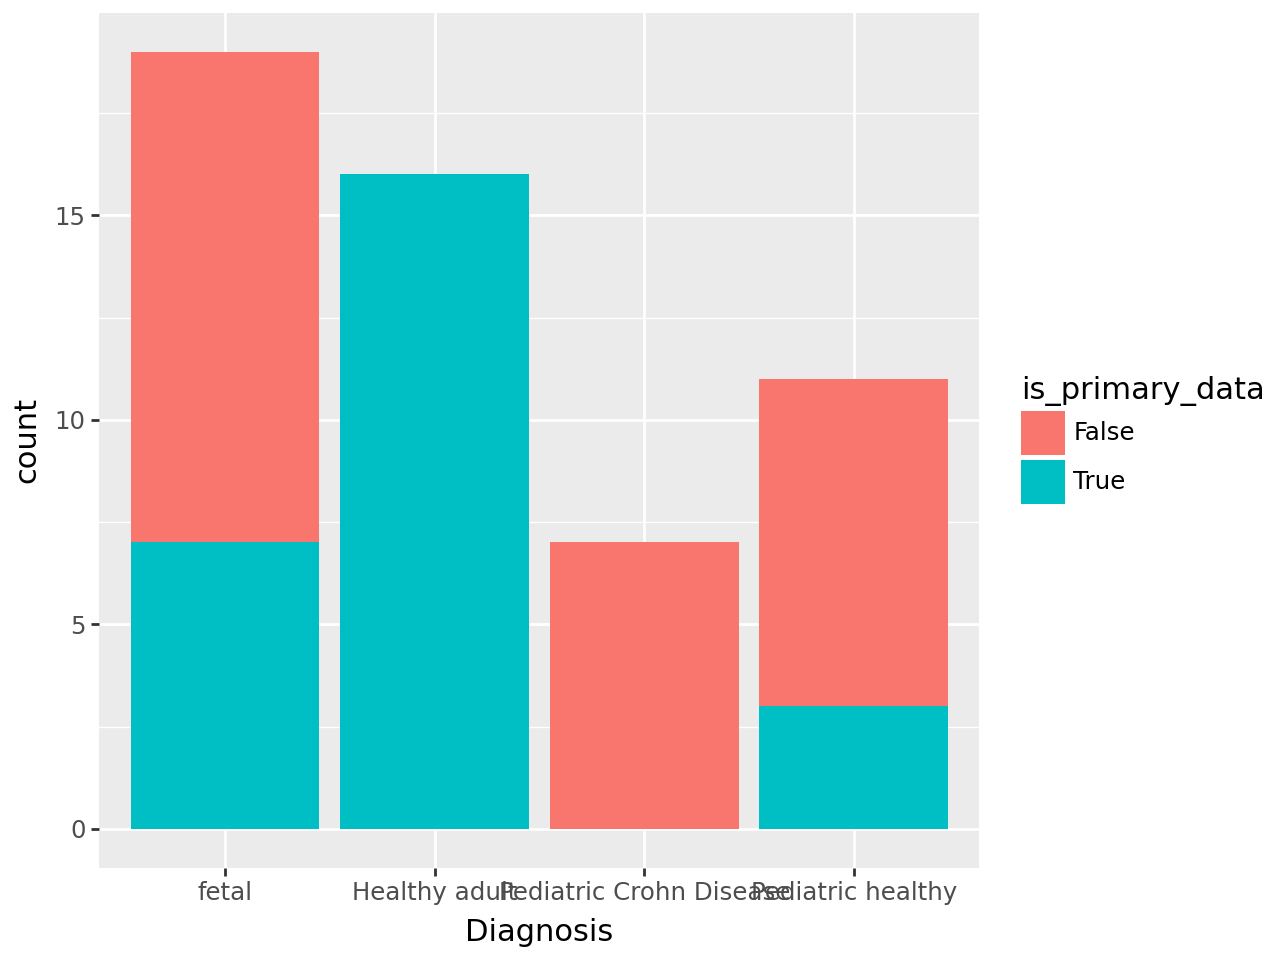

In [106]:
p3 = (ggplot(d2, aes(x="Diagnosis", fill="Fraction"))
       + geom_bar())
p4 = (ggplot(d2, aes(x="Diagnosis", fill="assay"))
       + geom_bar())
p5 = (ggplot(d2, aes(x="Diagnosis", fill="is_primary_data"))
       + geom_bar())


p3
p4
p5

In [107]:
d2 = (pl.from_pandas(adata.obs)
       .select(["donor_id","batch", "Diagnosis","assay"])
       .unique())

d2

donor_id,batch,Diagnosis,assay
cat,cat,cat,cat
"""F78""","""FCA_gut8015061""","""fetal""","""10x 5' v2"""
"""T017""","""4918STDY7273964""","""Pediatric Crohn Disease""","""10x 3' v2"""
"""BRC2043""","""4918STDY7421299""","""fetal""","""10x 3' v2"""
"""A39 (440C)""","""Human_colon_16S8123915""","""Healthy adult""","""10x 5' v2"""
"""BRC2134""","""4918STDY7718977""","""fetal""","""10x 3' v2"""
…,…,…,…
"""BRC2258""","""FCA_gut9456322""","""fetal""","""10x 5' v2"""
"""BRC2258""","""FCA_gut9456313""","""fetal""","""10x 5' v2"""
"""BRC2133""","""4918STDY7717789""","""fetal""","""10x 3' v2"""


In [108]:
p6 = (ggplot(d2, aes(x="donor_id", fill="assay"))
 + geom_bar()
 + facet_wrap("~Diagnosis", scales="free") # Facet
 + theme(
     legend_position="none",
     axis_text_x=element_text(rotation=45, ha="right"),
     figure_size=(16, 6) # Making it wider helps when faceting
 )
)

In [109]:
save_as_pdf_pages([p3,p4,p5,p6], filename=f"{graphs_dir}02_processing_inspection.pdf")

/home/melrie/miniforge3/envs/hi/lib/python3.14/site-packages/plotnine/ggplot.py:797: PlotnineWarning: Filename: ../outputs/figures/00_initial_exploration/02_processing_inspection.pdf


In [110]:
# It turns out the 3' is named a bit differently to the 5' in the healthy adult and fetal data, otherwise the batch names don't tell us much, but they do seem to be our separate samples
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(pl.from_pandas(adata.obs).select("batch","Diagnosis","assay").filter(pl.col("Diagnosis")=="Healthy adult").unique())

shape: (81, 3)
┌────────────────────────┬───────────────┬───────────┐
│ batch                  ┆ Diagnosis     ┆ assay     │
│ ---                    ┆ ---           ┆ ---       │
│ cat                    ┆ cat           ┆ cat       │
╞════════════════════════╪═══════════════╪═══════════╡
│ Human_colon_16S8001878 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8117831 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8123909 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8000475 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8002626 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8123910 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8117830 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8002628 ┆ Healthy adult ┆ 10x 5' v2 │
│ WTDAtest7844024        ┆ Healthy adult ┆ 10x 3' v2 │
│ Human_colon_16S8123918 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8001867 ┆ Healthy adult ┆ 10x 5' v2 │
│ Human_colon_16S8000513 ┆ Healthy adult ┆ 10x 5' v2 │
│ WTDAtest7844020        ┆ Healthy adult ┆ 10x 3' 

### 3. Sequencing quality control:
- n_genes: number of genes
- n_genes_by_counts: apparently qc step, has the exact same values
- total_counts: QC plot below, looks good
- total_counts_mt: QC plot below, looks good
- pct_counts_mt: QC plot below, looks good
- doublet_scores: all resulted in a doublet rating of FALSE
- predicted_doublets: all FALSE

In [111]:
# Show they are the same
(adata.obs["n_genes"] == adata.obs["n_genes_by_counts"]).all()

np.True_

/home/melrie/miniforge3/envs/hi/lib/python3.14/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


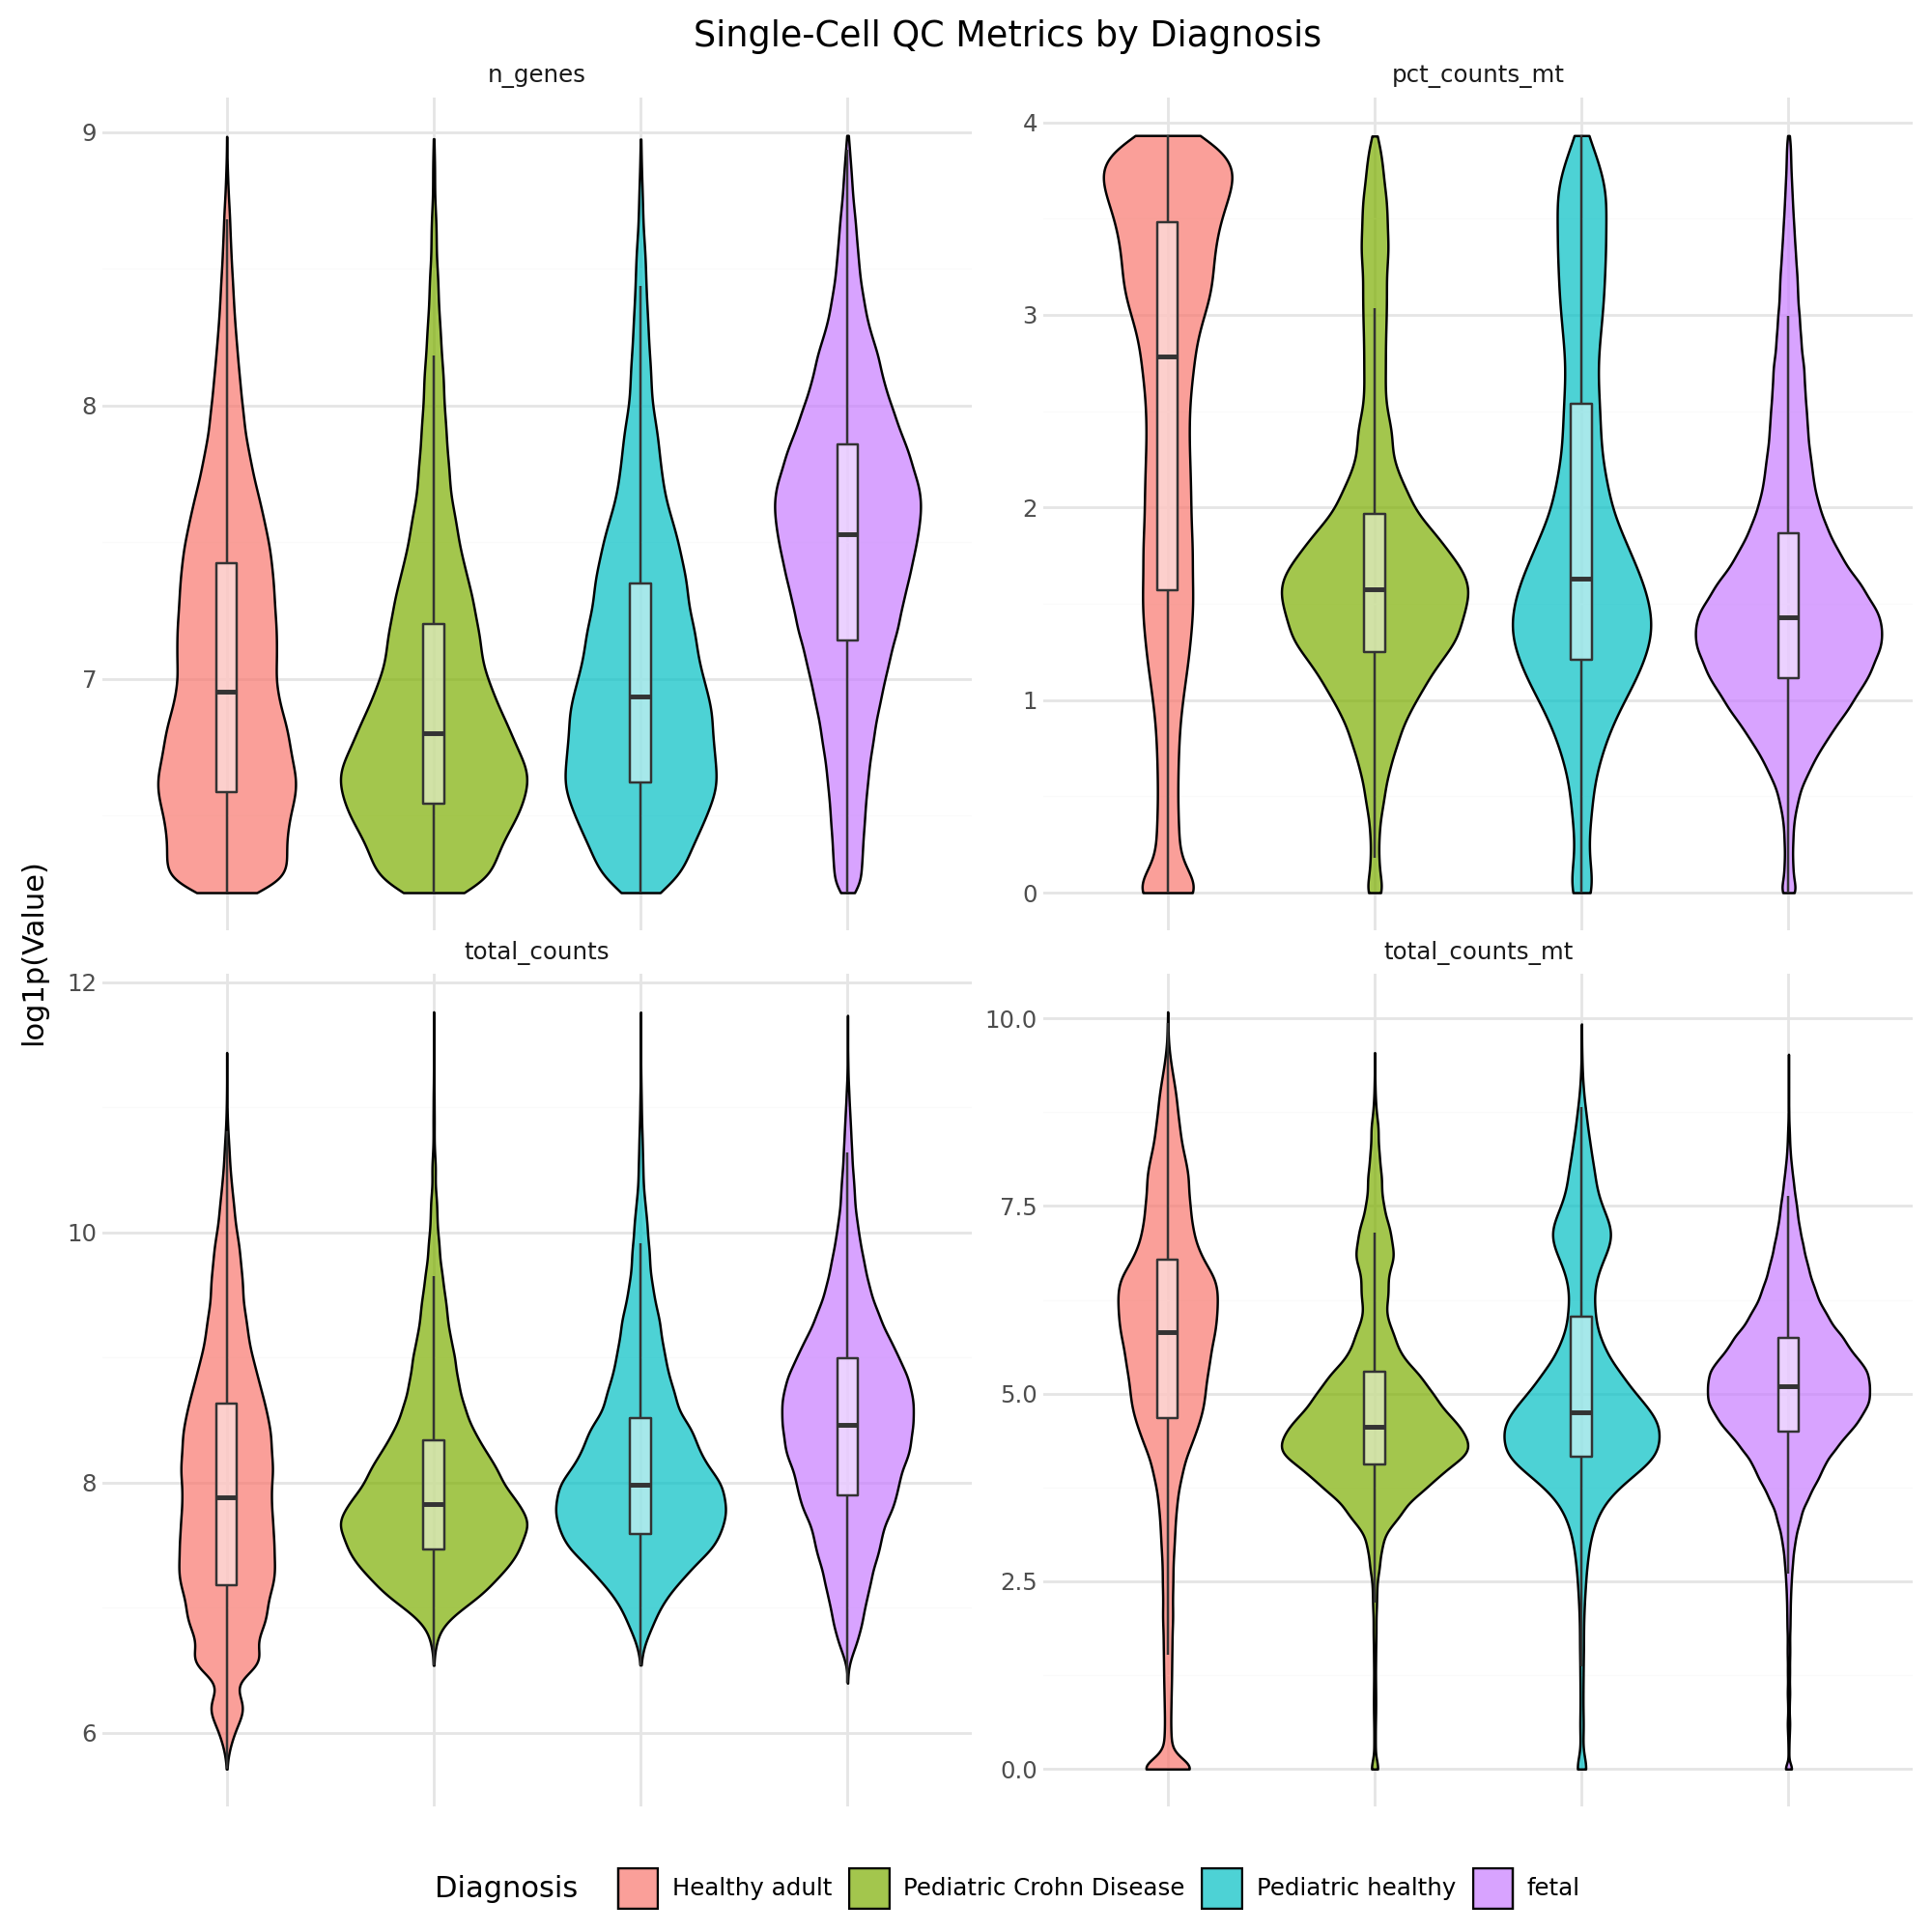

In [112]:
# 1. Prepare the data with n_genes included
metrics = ['total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes']
plot_df = adata.obs[['Diagnosis'] + metrics].copy()

# Apply log1p to all numeric columns for consistency
for metric in metrics:
    plot_df[metric] = np.log1p(plot_df[metric])

# 2. Melt for faceting
df_melted = plot_df.melt(id_vars='Diagnosis', var_name='Metric', value_name='Log_Value')

# 3. Plot with 2x2 Layout
plot = (
    ggplot(df_melted, aes(x='Diagnosis', y='Log_Value', fill='Diagnosis'))
    + geom_violin(alpha=0.7, color="black", size=0.5)
    + geom_boxplot(width=0.1, fill="white", outlier_shape=None, alpha=0.5)
    # scales='free_y' is vital here as pct_counts and total_counts have different ranges
    + facet_wrap('~Metric', scales='free_y', nrow=2, ncol=2) 
    + theme_minimal()
    + theme(
        axis_text_x=element_blank(),
        axis_ticks_major_x=element_blank(),
        legend_position='bottom',      # Keep the legend at the bottom to save space
        subplots_adjust={'wspace': 0.3, 'hspace': 0.4},
        figure_size=(10, 10)           # 10x10 is better for a 2x2 square grid
    )
    + labs(
        x="", 
        y="log1p(Value)", 
        title="Single-Cell QC Metrics by Diagnosis"
    )
)

plot

In [113]:
save_as_pdf_pages([plot], filename=f"{graphs_dir}03_sequencing_inspection.pdf")

/home/melrie/miniforge3/envs/hi/lib/python3.14/site-packages/plotnine/ggplot.py:797: PlotnineWarning: Filename: ../outputs/figures/00_initial_exploration/03_sequencing_inspection.pdf
/home/melrie/miniforge3/envs/hi/lib/python3.14/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.



### 4. Biological labels
- Category: Broad cell types
- author_cell_type: detailed cell types probably based on authors expertise (134)
- celltype (ontology_term_id): IDs that can be mapped to cell types
- development_stage (ontology_term_id): IDs that can be mapped to development stages
- hca_data_portal_donor_uuid: Biological replicates, donor id in the human cell atlas
- hca_data_portal_cellsuspension_uuid: Experimental replicates, the suspension tube that was made in the lab
- tissue (ontology_term_id): Tissue type

In [114]:
(pl.from_pandas(adata.obs).select("category").unique())

category
cat
"""Red blood cells"""
"""T cells"""
"""Epithelial"""
"""B cells"""
"""Mesenchymal"""
"""Plasma cells"""
"""Myeloid"""
"""Neuronal"""
"""Endothelial"""


In [115]:
(pl.from_pandas(adata.obs).select("author_cell_type").unique())
(pl.from_pandas(adata.obs).select("author_cell_type").n_unique())

author_cell_type
cat
"""DZ GC cell"""
"""Memory B"""
"""Mature venous EC"""
"""Cycling plasma cell"""
"""D cells (SST+)"""
…
"""Œ≤ cells (INS+)"""
"""CLDN10+ cells"""
"""EC cells (NPW+)"""


134

In [116]:
(pl.from_pandas(adata.obs).select("cell_type").unique())
(pl.from_pandas(adata.obs).select("cell_type").n_unique())

cell_type
cat
"""transit amplifying cell"""
"""mature NK T cell"""
"""endothelial cell of artery"""
"""IgG plasma cell"""
"""M cell of gut"""
…
"""mesothelial cell"""
"""colonocyte"""
"""CD8-positive, alpha-beta memor…"


83

In [117]:
(pl.from_pandas(adata.obs).select("development_stage").unique().to_series().to_list())
(pl.from_pandas(adata.obs).select("development_stage").n_unique())

['14-year-old stage',
 'third decade stage',
 '4-year-old stage',
 '6-year-old stage',
 '17th week post-fertilization stage',
 '10th week post-fertilization stage',
 'eighth decade stage',
 'Carnegie stage 19',
 '16th week post-fertilization stage',
 'Carnegie stage 22',
 '13-year-old stage',
 '15th week post-fertilization stage',
 '12th week post-fertilization stage',
 'seventh decade stage',
 '9-year-old stage',
 '12-year-old stage',
 'Carnegie stage 16',
 'Carnegie stage 17',
 'Carnegie stage 23',
 '11th week post-fertilization stage',
 'fifth decade stage',
 '10-year-old stage',
 'sixth decade stage',
 'Carnegie stage 20',
 '11-year-old stage']

25

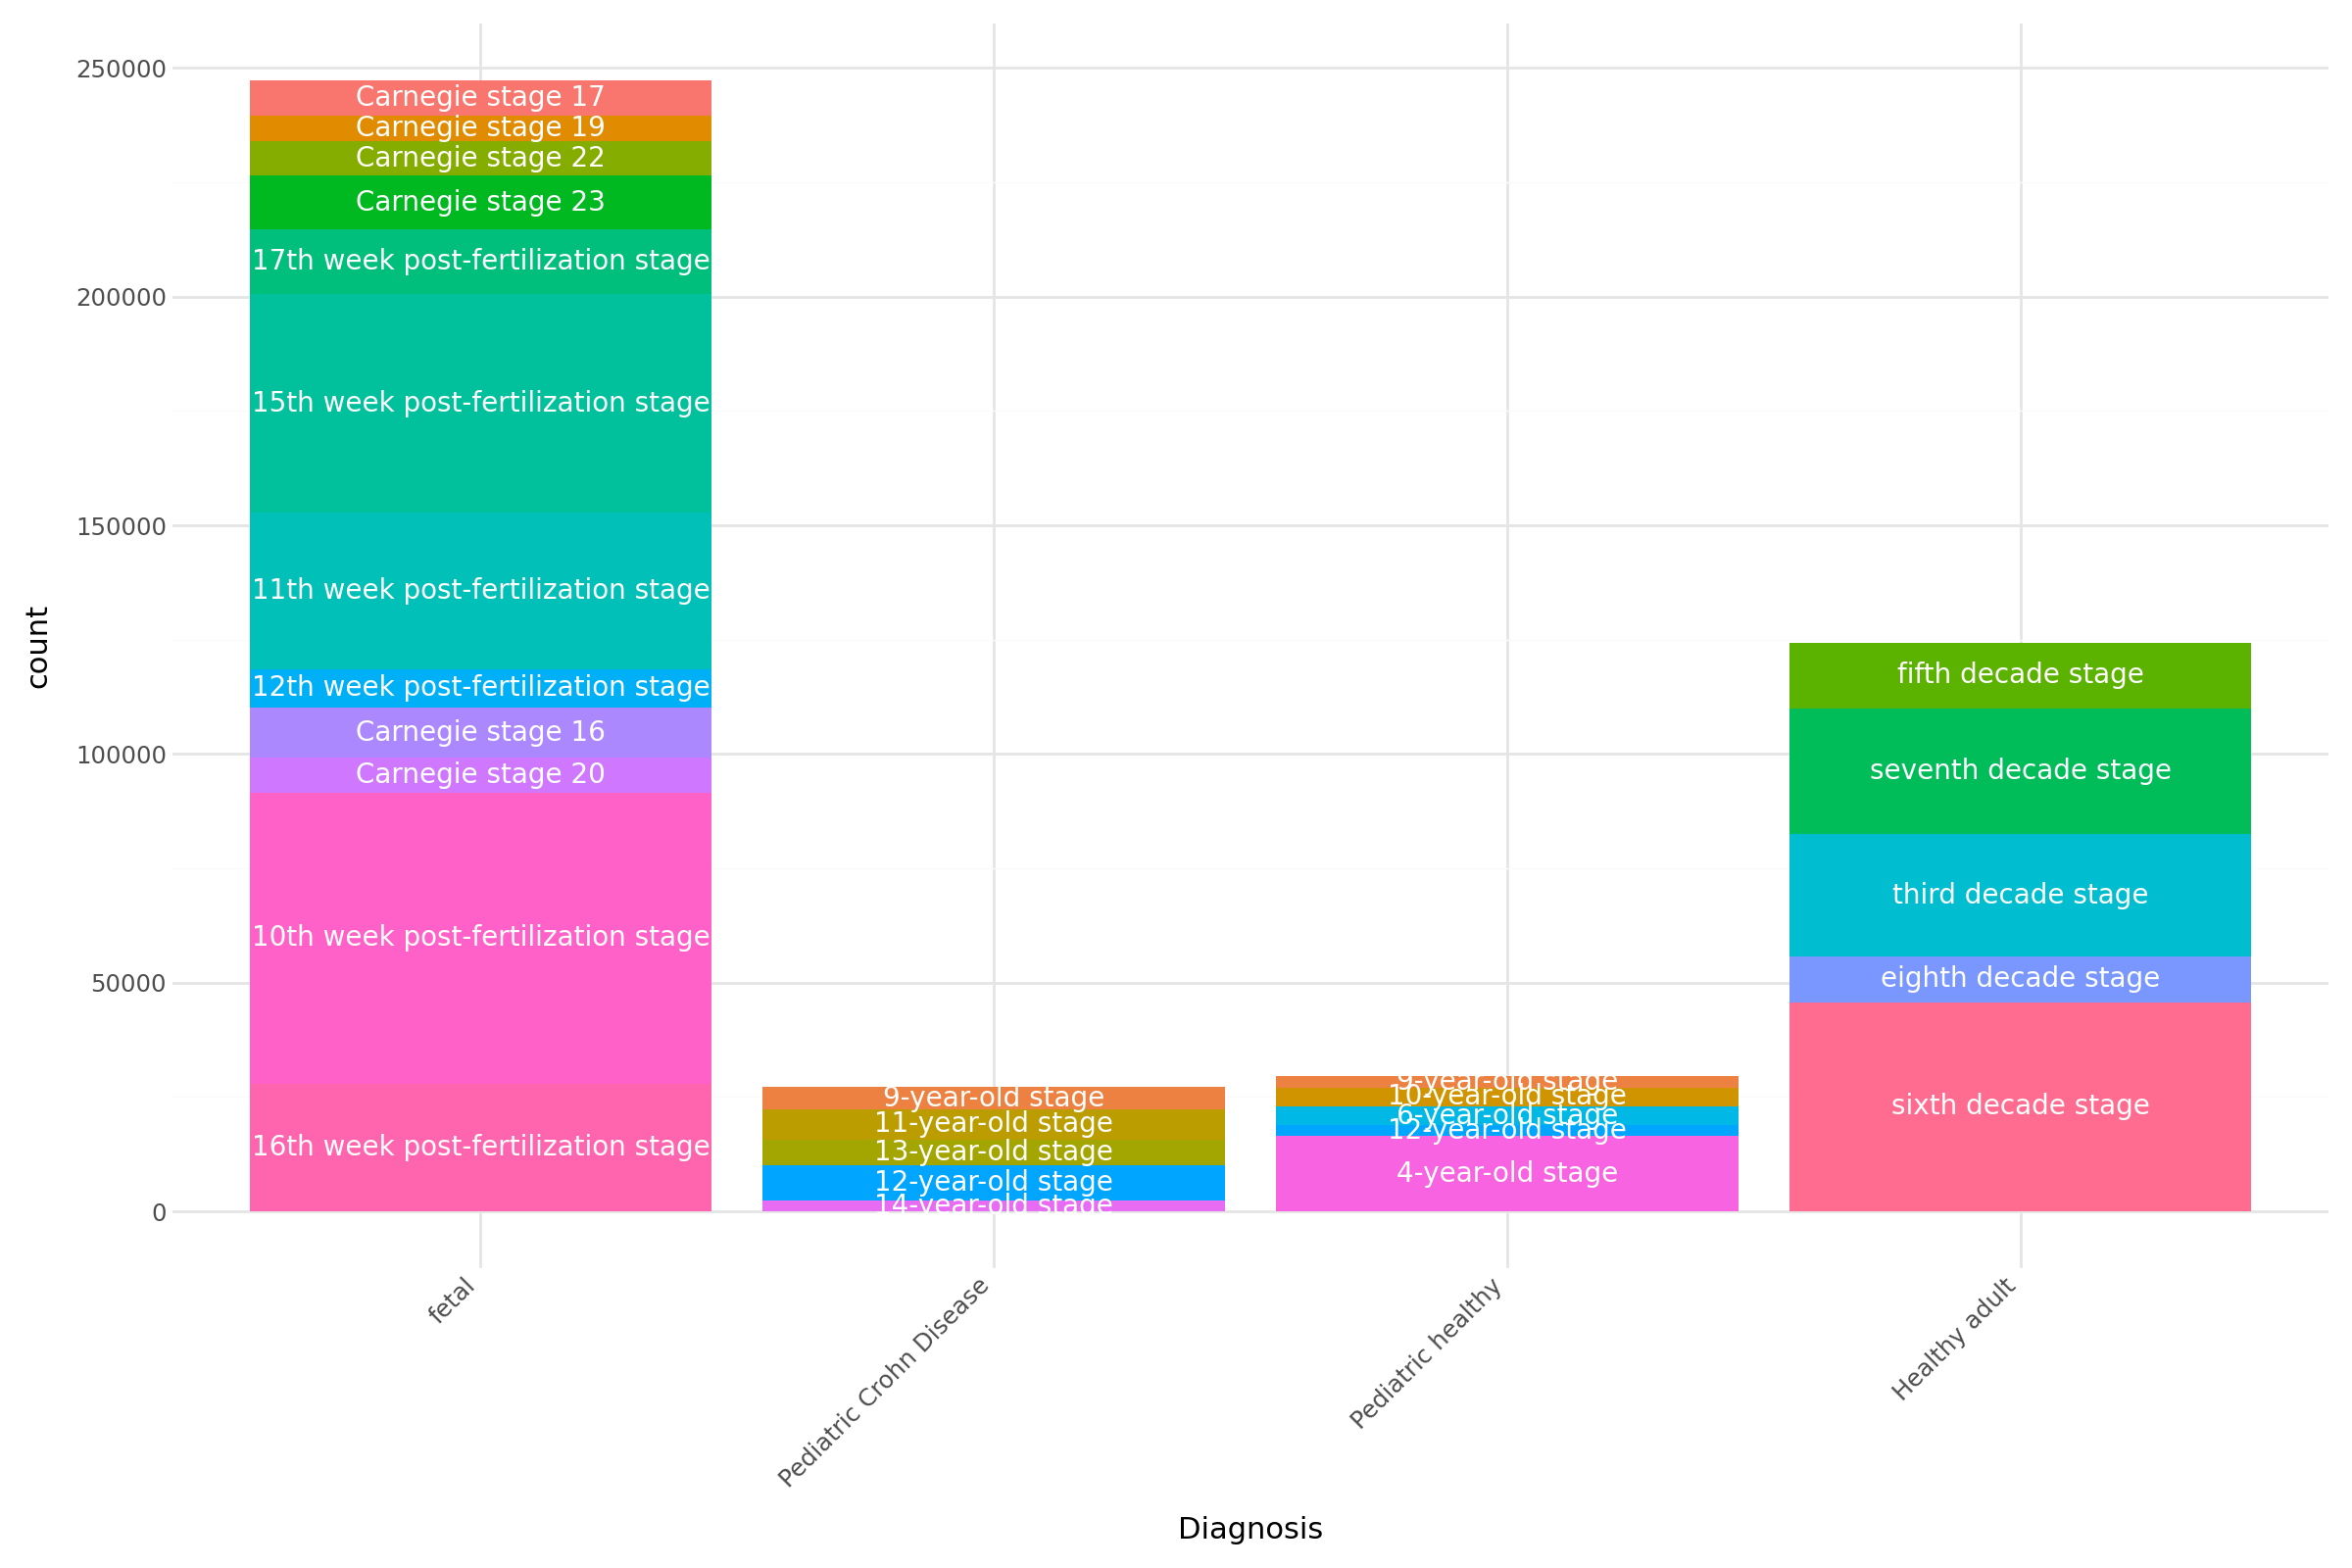

In [118]:
df = (
    pl.from_pandas(adata.obs)
    .group_by(["Diagnosis", "development_stage"])
    .len(name="count")
)
p = (
    ggplot(df, aes(x="Diagnosis", y="count", fill="development_stage"))
    + geom_col()  # Use geom_col when you have pre-calculated heights
    + geom_text(
        aes(label="development_stage"),
        position=position_stack(vjust=0.5), # Centers text in the bar segment
        size=10,
        color="white" # Or "black" depending on your fill colors
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        legend_position="none", # Remove the legend entirely
        axis_text_x=element_text(rotation=45, ha='right')
    )
)
p

In [119]:
import polars as pl

df = (
    pl.from_pandas(adata.obs)
    .group_by(["donor_id", "batch", "hca_data_portal_donor_uuid", "hca_data_portal_cellsuspension_uuid", "Diagnosis", "assay"])
    .len()
    .with_columns(
        source_label = pl.when(pl.col("hca_data_portal_donor_uuid") != "None")
                       .then(pl.lit("HCA"))
                       .otherwise(pl.col("hca_data_portal_donor_uuid"))
    )
)

print(df)
df

print(df["source_label"].value_counts())

shape: (159, 8)
┌────────────┬─────────────┬─────────────┬────────────┬────────────┬───────────┬──────┬────────────┐
│ donor_id   ┆ batch       ┆ hca_data_po ┆ hca_data_p ┆ Diagnosis  ┆ assay     ┆ len  ┆ source_lab │
│ ---        ┆ ---         ┆ rtal_donor_ ┆ ortal_cell ┆ ---        ┆ ---       ┆ ---  ┆ el         │
│ cat        ┆ cat         ┆ uuid        ┆ suspension ┆ cat        ┆ cat       ┆ u32  ┆ ---        │
│            ┆             ┆ ---         ┆ …          ┆            ┆           ┆      ┆ cat        │
│            ┆             ┆ cat         ┆ ---        ┆            ┆           ┆      ┆            │
│            ┆             ┆             ┆ cat        ┆            ┆           ┆      ┆            │
╞════════════╪═════════════╪═════════════╪════════════╪════════════╪═══════════╪══════╪════════════╡
│ A34 (417C) ┆ Human_colon ┆ c6693ae1-f3 ┆ a02b9cbc-3 ┆ Healthy    ┆ 10x 5' v2 ┆ 396  ┆ HCA        │
│            ┆ _16S8000477 ┆ ae-43d5-943 ┆ 0d3-4a3f-b ┆ adult      ┆       

donor_id,batch,hca_data_portal_donor_uuid,hca_data_portal_cellsuspension_uuid,Diagnosis,assay,len,source_label
cat,cat,cat,cat,cat,cat,u32,cat
"""A34 (417C)""","""Human_colon_16S8000477""","""c6693ae1-f3ae-43d5-9431-1bc14b…","""a02b9cbc-30d3-4a3f-bb65-a6accb…","""Healthy adult""","""10x 5' v2""",396,"""HCA"""
"""A33 (414C)""","""WTDAtest7844018""","""None""","""None""","""Healthy adult""","""10x 3' v2""",9485,"""None"""
"""A34 (417C)""","""Human_colon_16S8000473""","""c6693ae1-f3ae-43d5-9431-1bc14b…","""b75d9325-9931-4223-93c3-63f45e…","""Healthy adult""","""10x 5' v2""",255,"""HCA"""
"""A39 (440C)""","""Human_colon_16S8123921""","""d724f8a5-e655-4c05-b4ef-a1f3b1…","""6e380e54-8edf-4888-be12-2605ec…","""Healthy adult""","""10x 5' v2""",5619,"""HCA"""
"""A34 (417C)""","""Human_colon_16S8001865""","""c6693ae1-f3ae-43d5-9431-1bc14b…","""db8377da-0b33-4f3e-a267-ef4bf3…","""Healthy adult""","""10x 5' v2""",3233,"""HCA"""
…,…,…,…,…,…,…,…
"""F78""","""FCA_gut8015061""","""7b9c04f3-86a2-4087-9ff9-740ec2…","""b239eef7-9851-4650-8e85-f0a61a…","""fetal""","""10x 5' v2""",5082,"""HCA"""
"""A26 (386C)""","""Human_colon_16S8117830""","""54c59671-394f-4163-b098-336d6b…","""95f12a4f-1071-4529-8a55-5b74d6…","""Healthy adult""","""10x 5' v2""",2376,"""HCA"""
"""BRC2121""","""4918STDY7693763""","""d2fea39e-97a7-4107-8582-431355…","""78c5749b-649e-4429-bc39-902619…","""fetal""","""10x 3' v2""",4307,"""HCA"""


shape: (2, 2)
┌──────────────┬───────┐
│ source_label ┆ count │
│ ---          ┆ ---   │
│ cat          ┆ u32   │
╞══════════════╪═══════╡
│ HCA          ┆ 134   │
│ None         ┆ 25    │
└──────────────┴───────┘


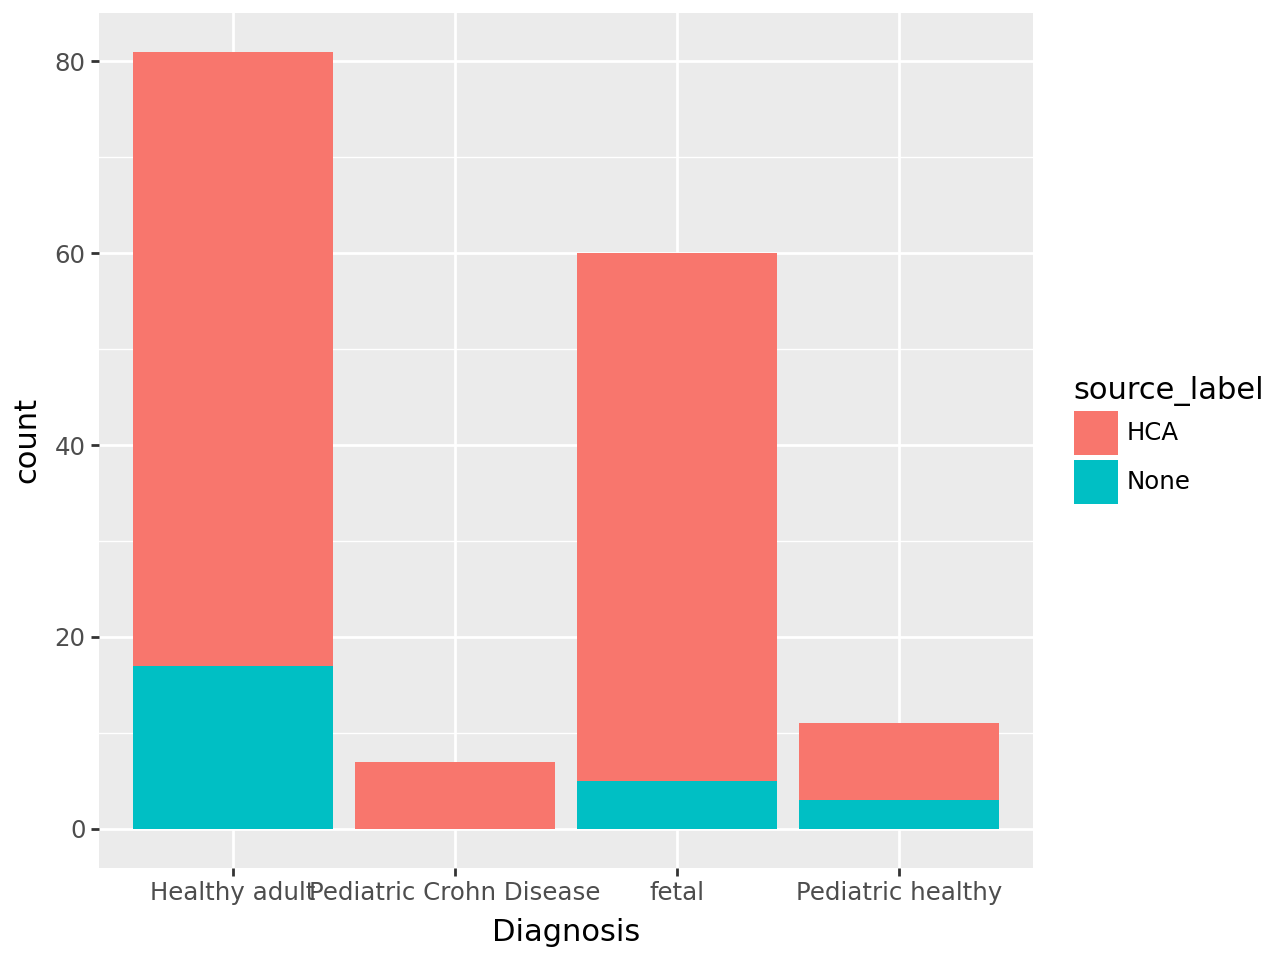

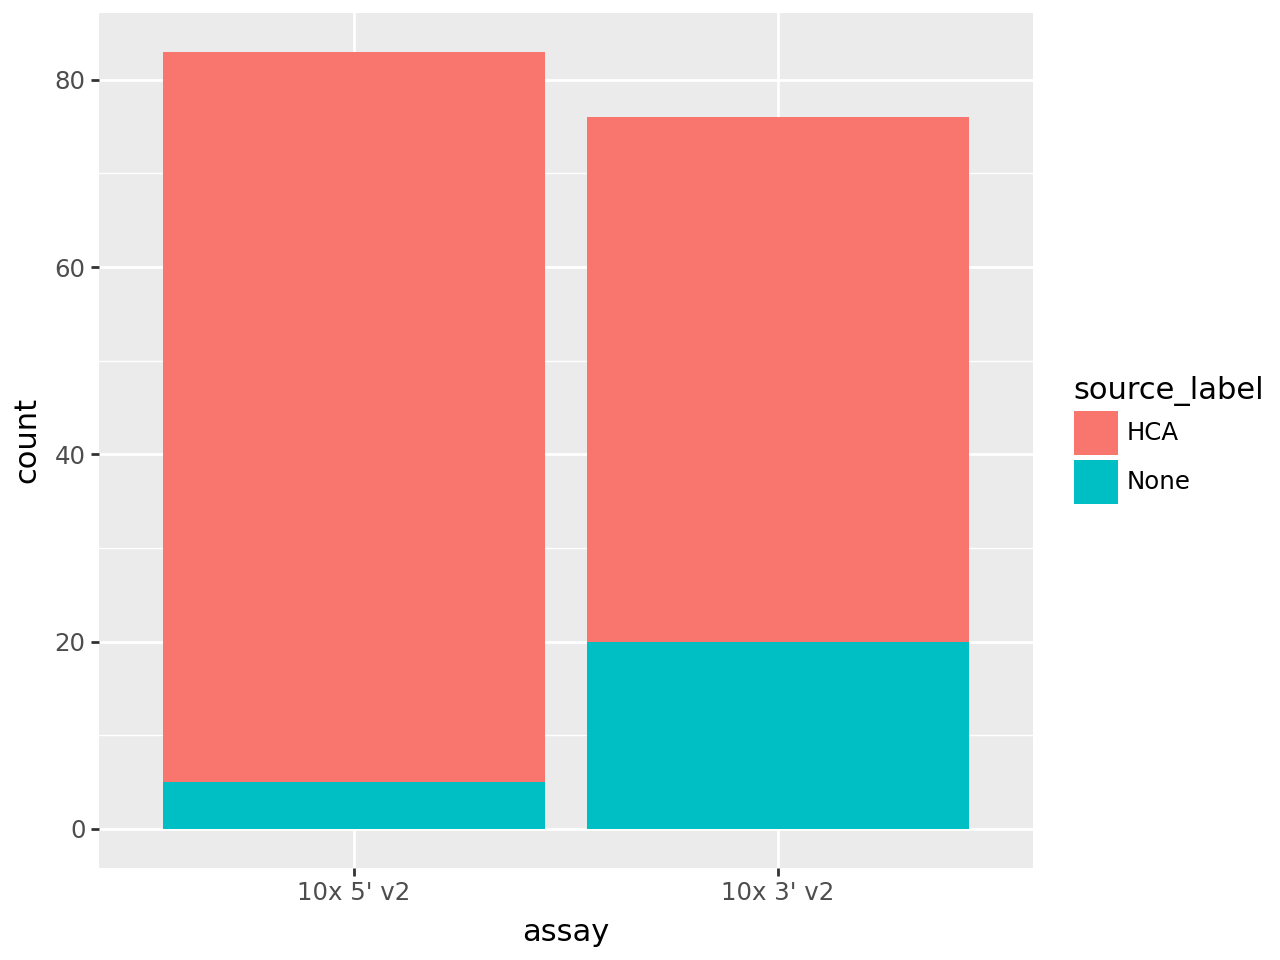

In [120]:
(ggplot(df, aes(x="Diagnosis", fill = "source_label"))
        + geom_bar())

(ggplot(df, aes(x="assay", fill = "source_label"))
        + geom_bar())

In [121]:
df = (pl.from_pandas(adata.obs)
    .select("donor_id", "Diagnosis","tissue")
    .unique()
    .sort(pl.col("Diagnosis").cast(pl.String).str.to_lowercase())) #change fetal to Fetal in final metadata reformatting
df

donor_id,Diagnosis,tissue
cat,cat,cat
"""BRC2043""","""fetal""","""ileum"""
"""BRC2043""","""fetal""","""duodenum"""
"""F66""","""fetal""","""ileum"""
"""F78""","""fetal""","""ileum"""
"""BRC2133""","""fetal""","""duodenum"""
…,…,…
"""T036""","""Pediatric healthy""","""ileum"""
"""T044""","""Pediatric healthy""","""ileum"""
"""T161""","""Pediatric healthy""","""ileum"""


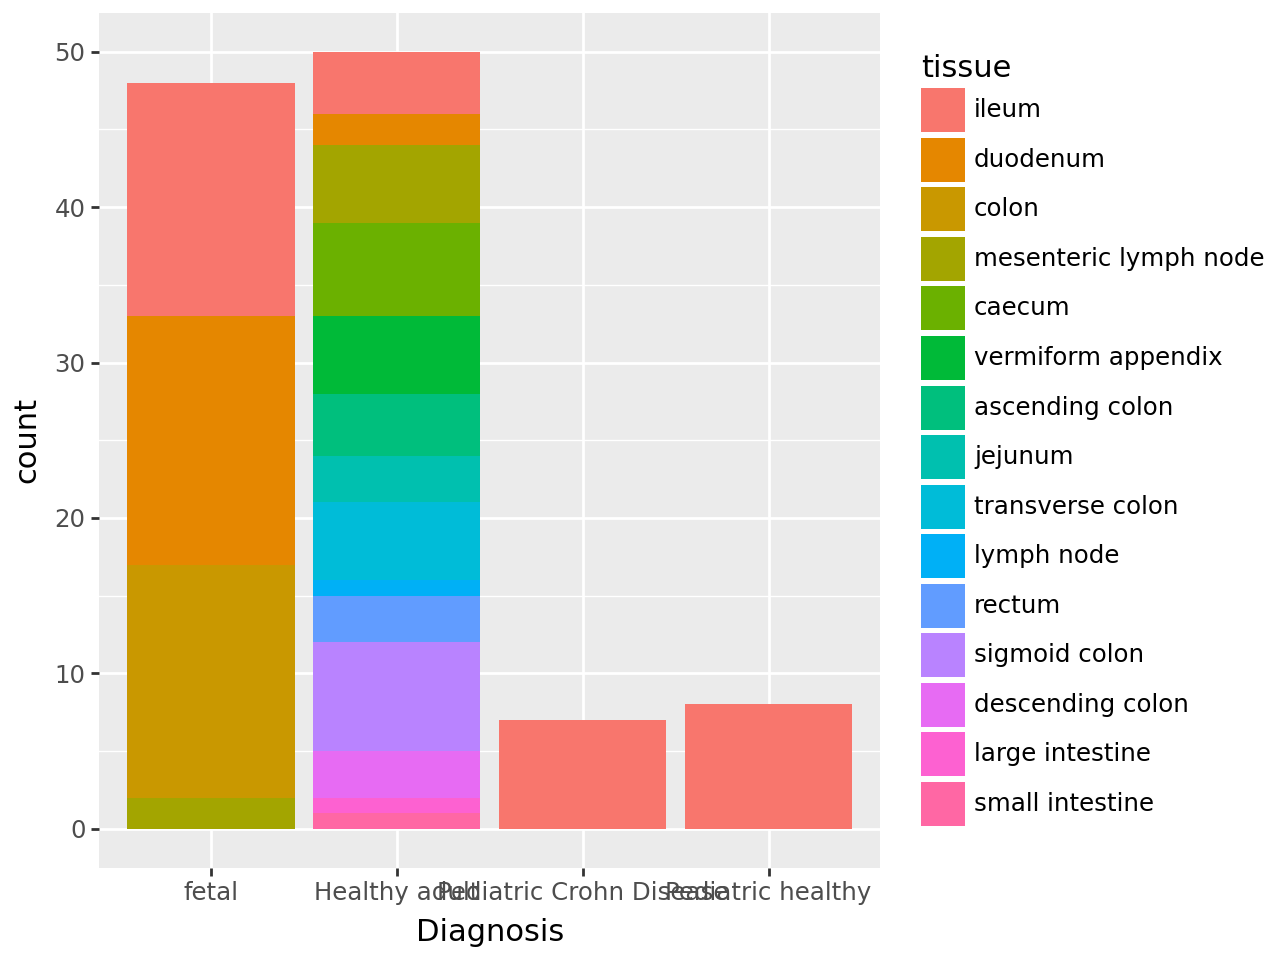

In [122]:
(ggplot(df, aes(x="Diagnosis", fill = "tissue"))
    + geom_bar())

### Redundant:
- suspension_type: only cell
- tissue_type: only tissue